In [ ]:
# !pip install xgboost

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/processed_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df_clean = df.dropna().copy()
print(f"Data shape: {df_clean.shape}")
df_clean.head()


Data shape: (261083, 32)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
52,1,1,2011-02-04,21665.76,0,2011,2,5,42.27,2.989,...,17341.47,15984.24,31497.65,24924.50,17286.6475,1013.925386,25087.749167,12701.860945,19720.954335,23775.964205
53,1,1,2011-02-11,37887.17,1,2011,2,6,36.39,3.022,...,18461.18,17359.70,44912.86,46039.49,18707.0275,2040.798674,25264.113333,12632.473744,20498.876601,23451.317404
54,1,1,2011-02-18,46845.87,0,2011,2,7,57.36,3.045,...,21665.76,17341.47,55931.23,41595.55,23838.8950,9543.110891,26791.974167,12982.799578,27454.193961,25672.217804
55,1,1,2011-02-25,19363.83,0,2011,2,8,62.90,3.065,...,37887.17,18461.18,19124.58,19403.54,31214.9950,13449.781394,29127.439167,13906.316950,35210.864376,28929.702757
56,1,1,2011-03-04,20327.61,0,2011,3,9,59.58,3.288,...,46845.87,21665.76,15984.24,21827.90,31440.6575,13169.111324,28864.628333,14071.411666,28872.050626,27458.030025


In [2]:
df_clean["Date"].max()

Timestamp('2012-10-26 00:00:00')

In [3]:
df_clean["Date"].min()

Timestamp('2011-02-04 00:00:00')

In [4]:
df_clean.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Year', 'Month',
       'Week', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size',
       'Type_A', 'Type_B', 'Type_C', 'Lag_1', 'Lag_2', 'Lag_4', 'Lag_8',
       'Lag_52', 'Sales_Roll_Mean_4', 'Sales_Roll_Std_4', 'Sales_Roll_Mean_12',
       'Sales_Roll_Std_12', 'Sales_EMA_4', 'Sales_EMA_12'],
      dtype='object')

In [5]:
train_data = df_clean[df_clean["Date"] < "2012-03-01"]
val_data = df_clean[(df_clean["Date"] >= "2012-03-01") & (df_clean["Date"] < "2012-10-26")]

feature_cols = [
    "IsHoliday", "Year", "Month", "Week",'Store','Dept',
    "Lag_1", "Lag_2", "Lag_4", "Lag_8", "Lag_52",
    "Sales_Roll_Mean_4", "Sales_Roll_Std_4",
    "Sales_Roll_Mean_12", "Sales_Roll_Std_12",
    "Sales_EMA_4", "Sales_EMA_12",'Size'
]
target = "Weekly_Sales"

X_train, y_train = train_data[feature_cols], train_data[target]
X_val, y_val = val_data[feature_cols], val_data[target]

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")


Training shape: (159474, 18)
Validation shape: (98686, 18)


In [6]:

baseline_preds = X_val["Lag_1"]
baseline_mae = mean_absolute_error(y_val, baseline_preds)
print(f"Naive Baseline (Lag-1) MAE: {baseline_mae:.2f}")
# {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1, max_features= "sqrt", min_samples_leaf= 2, min_samples_split= 2)
rf.fit(X_train, y_train)

preds = rf.predict(X_val)
model_mae = mean_absolute_error(y_val, preds)
print(f"Random Forest Regressor Validation MAE: {model_mae:.2f}")


Naive Baseline (Lag-1) MAE: 1655.82
Random Forest Regressor Validation MAE: 1302.12


In [7]:
preds

array([19416.85709762, 20644.7021955 , 20236.33852245, ...,
         551.7657091 ,   656.74318548,   971.71693206], shape=(98686,))

In [8]:
wmape = (np.sum(np.abs(y_val - preds)) / np.sum(y_val)) * 100

accuracy = 100 - wmape

print("MODEL PERFORMANCE IN PERCENTAGE:")
print(f"Weighted Error (wMAPE): {wmape:.2f}%")
print(f"Forecasting Accuracy:   {accuracy:.2f}%")


MODEL PERFORMANCE IN PERCENTAGE:
Weighted Error (wMAPE): 8.06%
Forecasting Accuracy:   91.94%


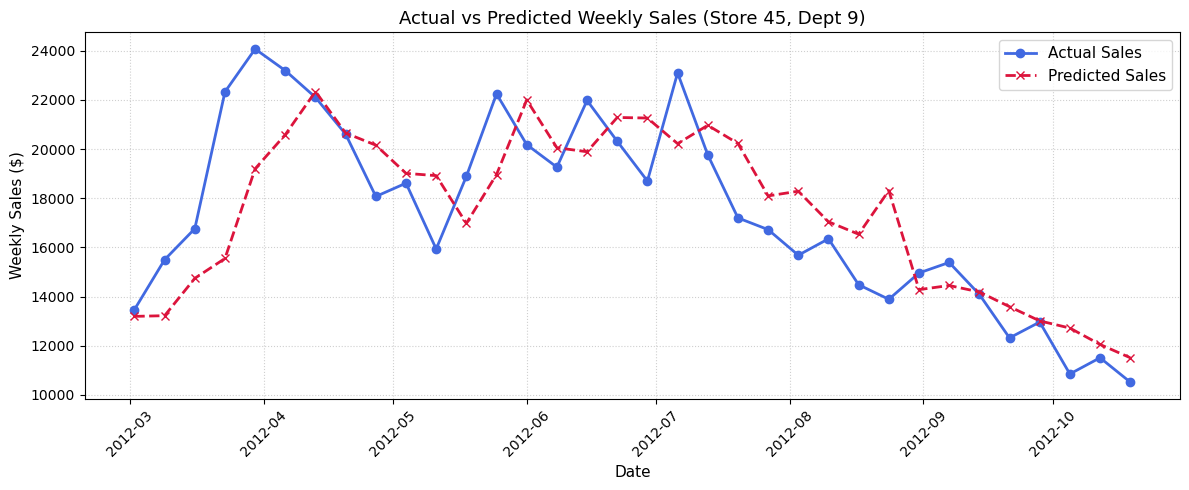

In [12]:
import matplotlib.pyplot as plt

val_plot = val_data.copy()
val_plot["Predicted_Sales"] = preds

select_store = 45
select_dept = 9

subset = val_plot[(val_plot["Store"] == select_store) & (val_plot["Dept"] == select_dept)].sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(subset["Date"], subset["Weekly_Sales"], label="Actual Sales", marker="o", color="royalblue", linewidth=2)
plt.plot(subset["Date"], subset["Predicted_Sales"], label="Predicted Sales", marker="x", linestyle="--", color="crimson", linewidth=2)

plt.title(f"Actual vs Predicted Weekly Sales (Store {select_store}, Dept {select_dept})", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Weekly Sales ($)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# holt model

In [10]:
model_mae = mean_absolute_error(subset["Weekly_Sales"], subset["Predicted_Sales"])
print(f"Random Forest Regressor Validation MAE: {model_mae:.2f}")

Random Forest Regressor Validation MAE: 5257.08


In [11]:
wmape = (np.sum(np.abs(subset["Weekly_Sales"] - subset["Predicted_Sales"])) / np.sum(subset["Weekly_Sales"])) * 100

accuracy = 100 - wmape

print("MODEL PERFORMANCE IN PERCENTAGE:")
print(f"Weighted Error (wMAPE): {wmape:.2f}%")
print(f"Forecasting Accuracy:   {accuracy:.2f}%")


MODEL PERFORMANCE IN PERCENTAGE:
Weighted Error (wMAPE): 11.80%
Forecasting Accuracy:   88.20%


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, _jobs=-1)

print("Training XGBoost Regressor...")
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_preds)
xgb_wmape = (np.sum(np.abs(y_val - xgb_preds)) / np.sum(y_val)) * 100
xgb_accuracy = 100 - xgb_wmape

print("\n--- XGBOOST MODEL PERFORMANCE ---")
print(f"XGBoost MAE:           ${xgb_mae:.2f}")
print(f"XGBoost wMAPE (Error): {xgb_wmape:.2f}%")
print(f"XGBoost Accuracy:      {xgb_accuracy:.2f}%")


In [ ]:

store_id = 1
dept_id = 1
series_data = df_clean[(df_clean["Store"] == store_id) & (df_clean["Dept"] == dept_id)].sort_values("Date")

series_data = series_data.set_index("Date")["Weekly_Sales"]
series_data = series_data.asfreq('W-FRI')

train_series = series_data[series_data.index < "2012-03-01"]
val_series = series_data[(series_data.index >= "2012-03-01") & (series_data.index < "2012-07-01")]

print(f"Training steps: {len(train_series)}, Validation steps: {len(val_series)}")


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_model = ARIMA(train_series, order=(1, 1, 1))
arima_result = arima_model.fit()

arima_preds = arima_result.predict(start=val_series.index[0], end=val_series.index[-1])

sarima_model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 1, 0, 52))
sarima_result = sarima_model.fit(disp=False)

sarima_preds = sarima_result.predict(start=val_series.index[0], end=val_series.index[-1])

In [ ]:
from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(val_series, arima_preds)
sarima_mae = mean_absolute_error(val_series, sarima_preds)

naive_mae = mean_absolute_error(val_series, np.full(len(val_series), train_series.iloc[-1]))

rf_subset = val_plot[(val_plot["Store"] == store_id) & (val_plot["Dept"] == dept_id)].sort_values("Date")
rf_mae = mean_absolute_error(rf_subset["Weekly_Sales"], rf_subset["Predicted_Sales"])

print(f"--- Performance Comparison (Store {store_id}, Dept {dept_id}) ---")
print(f"Naive Baseline MAE:  ${naive_mae:.2f}")
print(f"ARIMA MAE:           ${arima_mae:.2f}")
print(f"SARIMA MAE:          ${sarima_mae:.2f}")
print(f"Random Forest MAE:   ${rf_mae:.2f}")


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train_series)
plt.show()

plot_pacf(train_series)
plt.show()

# ACF tells value of q in arima model and in PACF it tells value of p
# values outside of confidence bounds are only considered 
# q= 1,7,8  and  p= 1,2,7,16


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Score:")
print(-grid_search.best_score_)

best_rf = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = best_rf.predict(X_valid)

mae = mean_absolute_error(y_valid, pred)
rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("MAE :", mae)
print("RMSE:", rmse)

In [ ]:

import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

results = results.sort_values("rank_test_score")

print(results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10))